## Exploratory Data Analysis

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
df = pd.read_parquet("consolidated_logistics_base.parquet")

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 82 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  str           
 5   order_delivered_carrier_date   111456 non-null  str           
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  str           
 10  seller_id                      112650 non-null  str           
 11  shipping_li

In [88]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,bert_svd_40,bert_svd_41,bert_svd_42,bert_svd_43,bert_svd_44,bert_svd_45,bert_svd_46,bert_svd_47,bert_svd_48,bert_svd_49
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,0.052455,-0.098109,0.146767,0.090446,0.280138,-0.106301,-0.437916,0.755499,0.160171,-0.121071
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,0.131755,0.058410,-0.147710,-0.116853,-0.269182,-0.241428,-0.200264,0.136254,-0.166536,0.043802
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,-0.003645,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,-0.177183,0.052156,-0.085034,0.380572,0.057153,0.047215,0.005328,-0.367307,-0.231086,0.072944
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,-0.003645,-0.001168,0.001993,0.000650,0.000121,-0.002988,0.000843,-0.000631,-0.002070,-0.001148


In [89]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,112650,98666,fc3d1daec319d62d49bfb5e1f83123e9,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,112650,7,delivered,110197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,112650,NaN,NaN,NaN,2018-01-01 00:09:48.464376,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000,2018-09-03 09:06:57,NaN
order_approved_at,112635,90174,2018-02-24 03:20:27,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
bert_svd_45,112650.0,NaN,NaN,NaN,0.000756,-1.528387,-0.002988,-0.002988,-0.002988,1.859551,0.22076
bert_svd_46,112650.0,NaN,NaN,NaN,-0.000007,-2.068421,0.000843,0.000843,0.000843,1.626035,0.217006
bert_svd_47,112650.0,NaN,NaN,NaN,0.000495,-2.021377,-0.000631,-0.000631,-0.000631,1.873505,0.213776
bert_svd_48,112650.0,NaN,NaN,NaN,0.00071,-2.029779,-0.00207,-0.00207,-0.00207,2.33475,0.211086


In [90]:
#Getting an idea of how much are the late orders.
df["is_late"].value_counts(dropna=False, normalize=True) 

is_late
0       0.900852
1       0.077364
<NA>    0.021784
Name: proportion, dtype: Float64

In [91]:
#Analysing Nulls
nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0].head(30)

review_comment_message           0.579139
order_delivered_customer_date    0.021784
is_late                          0.021784
product_category_name            0.014230
order_delivered_carrier_date     0.010599
review_score                     0.008362
seller_customer_distance_km      0.004918
customer_geo_city                0.002681
customer_geo_state               0.002681
seller_geo_state                 0.002246
seller_geo_city                  0.002246
product_volume_cm3               0.000160
product_weight_g                 0.000160
order_approved_at                0.000133
payment_type_main                0.000027
dtype: float64

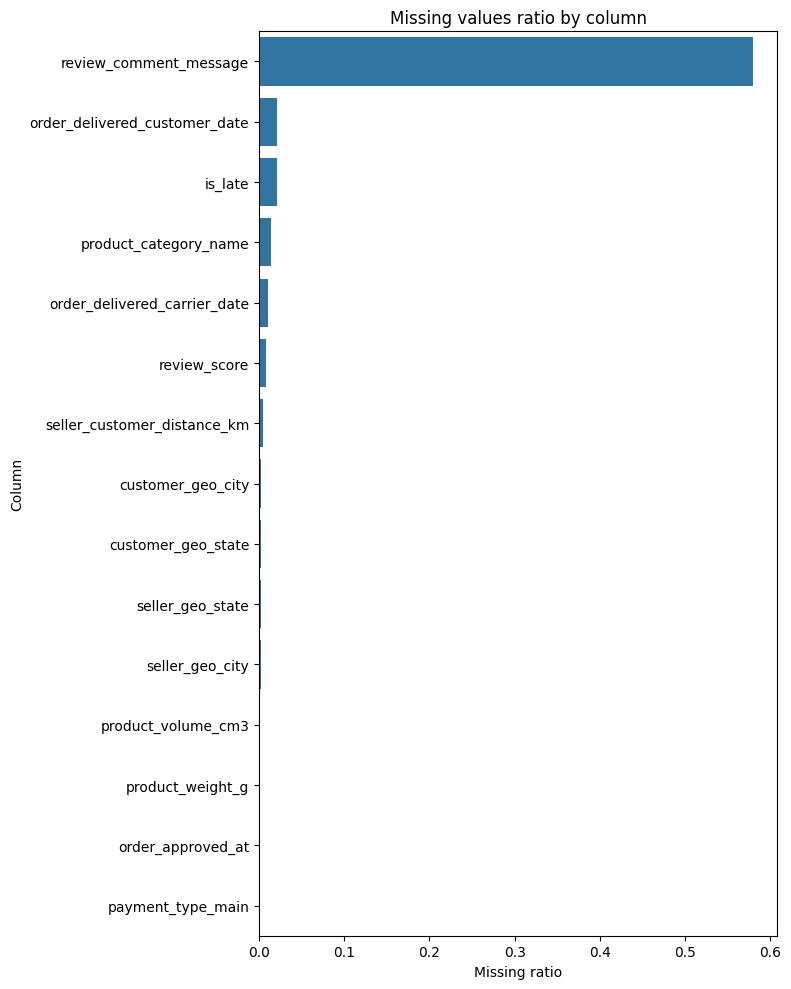

In [92]:
# Plot null ratios
plt.figure(figsize=(8, 10))
sns.barplot(x=nulls[nulls > 0], y=nulls[nulls > 0].index)
plt.title("Missing values ratio by column")
plt.xlabel("Missing ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Missing values - main observations:

- Some columns have a non‑negligible proportion of missing values, especially date fields related to delivery and review text fields.
- Columns with missing values are mostly expected (e.g. orders not delivered or without reviews), so they are likely informative rather than random noise.
- There are no columns with an extremely high null ratio that would be immediate candidates for dropping at this stage.
- We will need to handle missing values carefully during feature engineering, possibly with separate indicators (flags) for “missing” where it makes business sense.

In [93]:
# Derive delivery time columns to enhance features

df["actual_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["delay_vs_estimated_days"] = (
    df["actual_delivery_days"] - df["estimated_delivery_days"]
)

In [94]:
# Descriptive statistics for delivery times
df[["actual_delivery_days", "estimated_delivery_days", "delay_vs_estimated_days"]].describe()

,actual_delivery_days,estimated_delivery_days,delay_vs_estimated_days
count,110196.000000,112650.000000,110196.000000
mean,12.007723,23.470484,-11.433446
std,9.451455,8.884872,10.170284
min,0.000000,2.000000,-146.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,189.000000


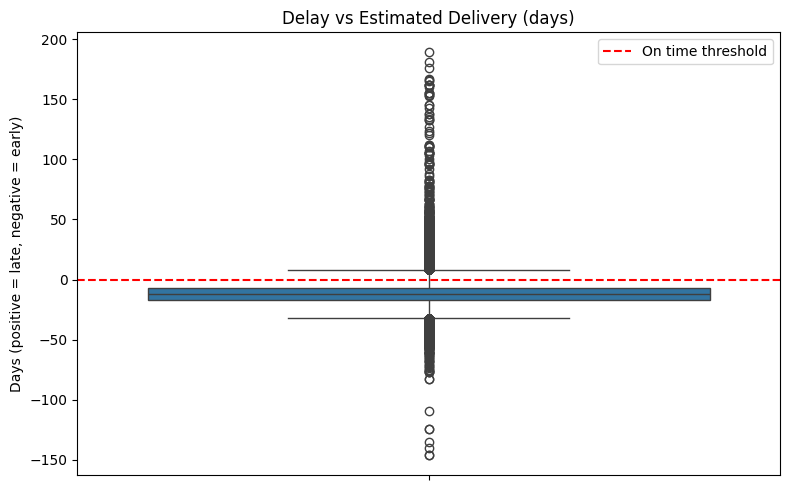

In [95]:
# Boxplot of delay vs estimated delivery days
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df[df["delay_vs_estimated_days"].notna()],
    y="delay_vs_estimated_days"
)
plt.axhline(0, color="red", linestyle="--", label="On time threshold")
plt.title("Delay vs Estimated Delivery (days)")
plt.ylabel("Days (positive = late, negative = early)")
plt.legend()
plt.tight_layout()
plt.show()

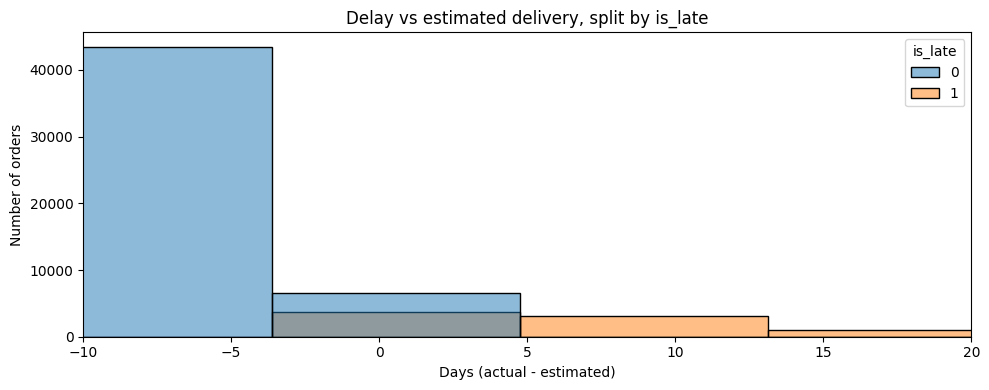

In [96]:
# Plot delay distribution split by is_late
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df[df["is_late"].notna()],
    x="delay_vs_estimated_days",
    hue="is_late",
    bins=40,
    kde=False,
    multiple="layer"
)
plt.xlim(-10, 20)
plt.title("Delay vs estimated delivery, split by is_late")
plt.xlabel("Days (actual - estimated)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

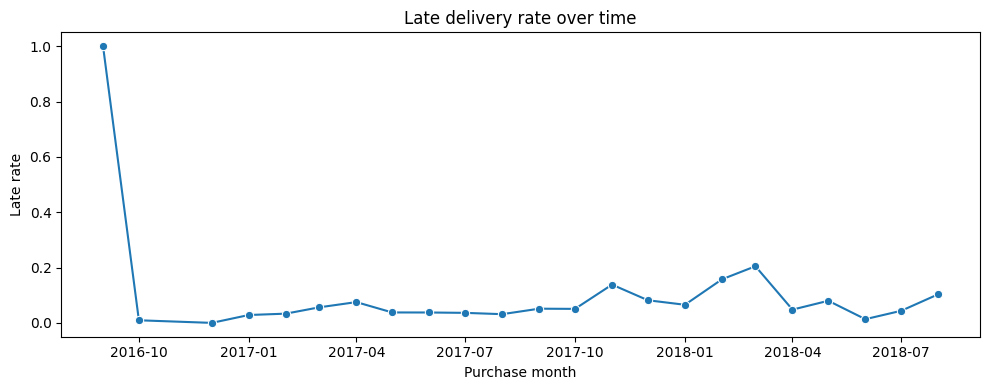

In [97]:
# Aggregate late rate by purchase month
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    df[df["is_late"].notna()]
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum()),
        ontime_orders=("is_late", lambda x: (x == 0).sum())
    )
)

monthly["late_rate"] = monthly["late_orders"] / (
    monthly["late_orders"] + monthly["ontime_orders"]
)
monthly.index = monthly.index.to_timestamp()

# Plot monthly late rate
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly, x=monthly.index, y="late_rate", marker="o")
plt.title("Late delivery rate over time")
plt.xlabel("Purchase month")
plt.ylabel("Late rate")
plt.tight_layout()
plt.show()

### Time series analysis – main findings:

- The `delay_vs_estimated_days` variable shows that many orders are delivered slightly before or very close to the estimated date, but there is a noticeable right tail of late deliveries.
- The histogram of `delay_vs_estimated_days` indicates that small positive delays (a few days) are relatively common, while very large delays are less frequent but still present.
- The boxplot split by `is_late` shows a clear separation between on‑time and late orders: late orders have a much higher median delay and a wider spread, which validates `delay_vs_estimated_days` as a strong candidate feature for the model.
- There is a peak of delays in an specific period between the end of 2017 and the firs trimester of 2018.

In [98]:
# Aggregate late rate by customer state
state_late = (
    df[df["is_late"].notna()]
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)

state_late["late_rate"] = state_late["late_orders"] / state_late["total_orders"]
state_late = state_late.sort_values("late_rate", ascending=False)

state_late

,total_orders,late_orders,late_rate
customer_state,,,
AL,397,103,0.259446
MA,717,163,0.227336
SE,335,61,0.18209
CE,1279,218,0.170446
PI,476,81,0.170168
BA,3256,504,0.154791
RJ,12353,1835,0.148547
TO,274,38,0.138686
PA,946,131,0.138478


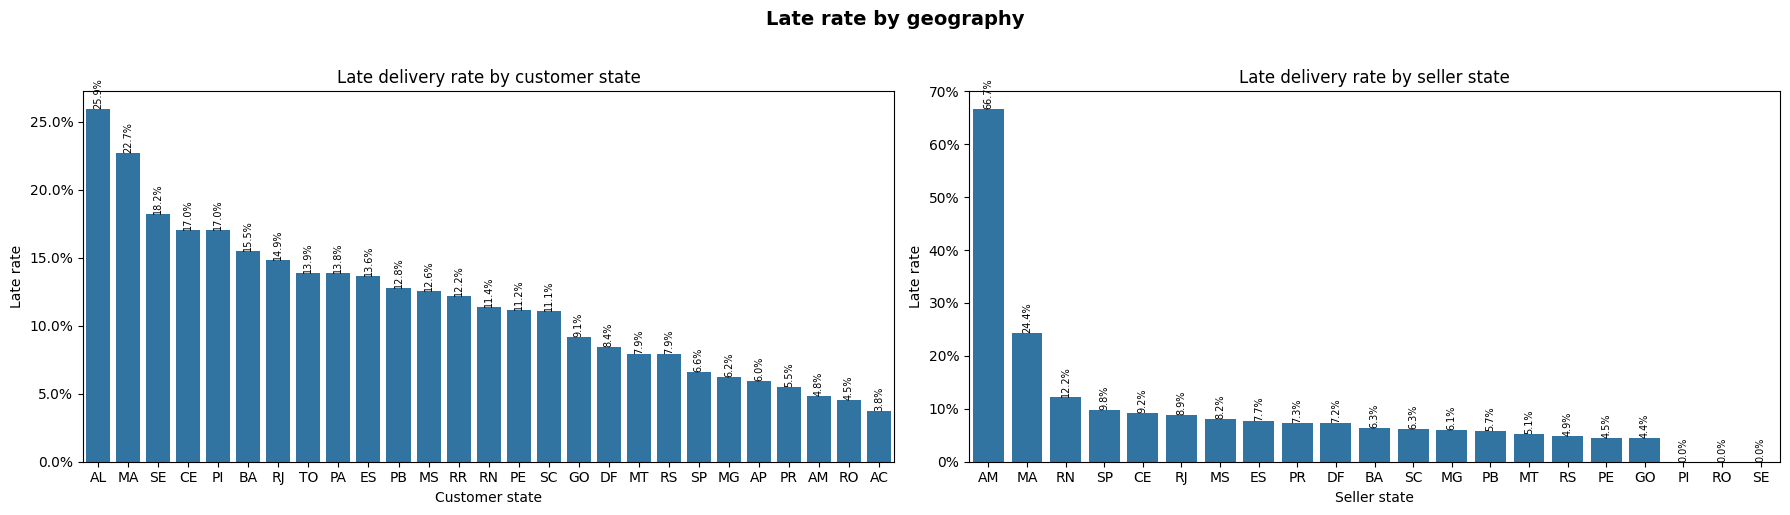

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Customer state ---
sns.barplot(
    data=state_late.reset_index(),
    x="customer_state",
    y="late_rate",
    order=state_late.index,
    ax=axes[0]
)

# Percentual annotations
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[0].set_title("Late delivery rate by customer state")
axes[0].set_xlabel("Customer state")
axes[0].set_ylabel("Late rate")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# --- Seller state ---
seller_state_late = (
    df[df["is_late"].notna()]
    .groupby("seller_geo_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)
seller_state_late["late_rate"] = (
    seller_state_late["late_orders"] / seller_state_late["total_orders"]
)
seller_state_late = seller_state_late.sort_values("late_rate", ascending=False)

sns.barplot(
    data=seller_state_late.reset_index(),
    x="seller_geo_state",
    y="late_rate",
    order=seller_state_late.index,
    ax=axes[1]
)

# Percentual annotations
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7, rotation=90
    )

axes[1].set_title("Late delivery rate by seller state")
axes[1].set_xlabel("Seller state")
axes[1].set_ylabel("Late rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.suptitle("Late rate by geography", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [100]:
df["seller_customer_distance_km"].describe()

count    112096.000000
mean        595.811161
std         588.022703
min           0.000000
25%         183.742470
50%         431.145464
75%         791.082689
max        8652.119722
Name: seller_customer_distance_km, dtype: float64

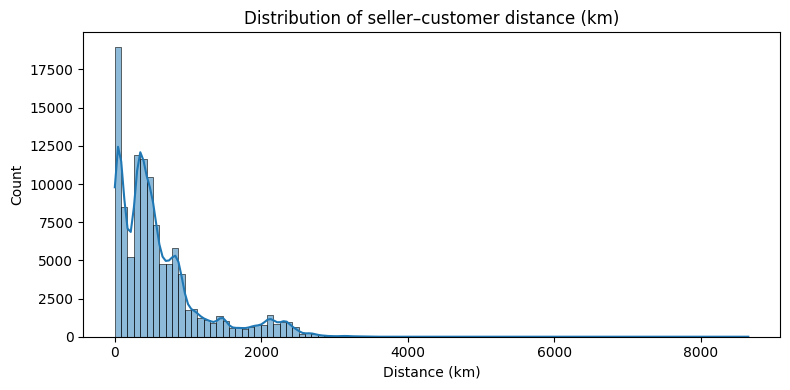

In [101]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="seller_customer_distance_km",
    bins=100,
    kde=True
)
plt.title("Distribution of seller–customer distance (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

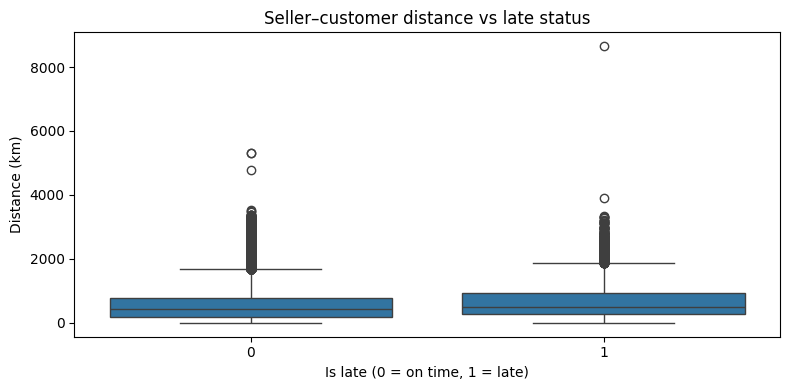

In [102]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="is_late",
    y="seller_customer_distance_km"
)
plt.title("Seller–customer distance vs late status")
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

  distance_bucket_km  total_orders  late_rate
0             0–50km         13469     0.0663
1           50–200km         14704   0.060392
2          200–500km         34825   0.070007
3           500km–1k         29449   0.082516
4              1k–2k         11030   0.106346
5              2k–5k          6180   0.135922
6                5k+             3   0.333333


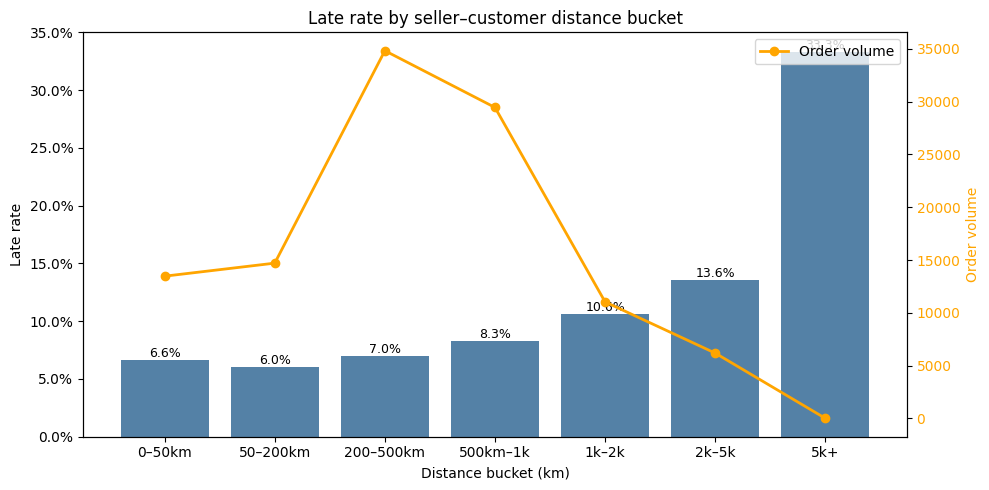

In [103]:
# Filter out NA before bucketing
df_geo = df[df["is_late"].notna() & df["seller_customer_distance_km"].notna()].copy()

# Late rate by distance bucket
bins   = [0, 50, 200, 500, 1000, 2000, 5000, 10000]
labels = ["0–50km", "50–200km", "200–500km", "500km–1k", "1k–2k", "2k–5k", "5k+"]

df_geo["distance_bucket_km"] = pd.cut(
    df_geo["seller_customer_distance_km"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

distance_late = (
    df_geo
    .groupby("distance_bucket_km", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", lambda x: (x == 1).sum() / len(x))  # evita ambiguidade do NA
    )
    .reset_index()
)

print(distance_late)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=distance_late,
    x="distance_bucket_km",
    y="late_rate",
    color="steelblue",
    ax=ax1
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_title("Late rate by seller–customer distance bucket")
ax1.set_xlabel("Distance bucket (km)")
ax1.set_ylabel("Late rate")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    distance_late.index,
    distance_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Geolocation analysis – main findings:

- **Distance matters**: Although the boxplot indicates similar behavior in within late or not orders, the barplot shows that the distance between seller and customer has a clear relationship with late deliveries; larger distance buckets exhibit significantly higher late rates compared to local/regional deliveries.
- **Seller hotspot of delays**: the seller state with the highest late rate, by a wide margin, is **Amazonas (AM)**, suggesting relevant logistical challenges for shipments originating from this region.
- **Customer hotspots of delays**: customer states in the **Northeast** concentrate some of the highest late rates in the dataset, indicating potential bottlenecks in the delivery network to that region.
- These findings reinforce the importance of including **geography and seller–customer distance** as core features in the delay prediction model.

In [104]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id', 'customer_city',
       'customer_state', 'review_comment_message', 'review_score',
       'product_category_name', 'product_weight_g', 'payment_type_main',
       'seller_geo_city', 'seller_geo_state', 'customer_geo_city',
       'customer_geo_state', 'seller_customer_distance_km', 'is_late',
       'product_volume_cm3', 'is_heavy_product', 'is_bulky_product',
       'has_comment', 'bert_svd_0', 'bert_svd_1', 'bert_svd_2', 'bert_svd_3',
       'bert_svd_4', 'bert_svd_5', 'bert_svd_6', 'bert_svd_7', 'bert_svd_8',
       'bert_svd_9', 'bert_svd_10', 'bert_svd_11', 'bert_svd_12',
       'bert_svd_13', 'bert_svd_14', 'bert_svd_15', 'bert_svd_16',
       '

In [105]:
cols_size = [
    "product_weight_g",
    "product_volume_cm3",
    "is_heavy_product",
    "is_bulky_product",
    "is_late",
]

df_eda = df[cols_size].dropna(subset=["is_late"]).copy()
df_eda["is_late"] = df_eda["is_late"].astype(int)
df_eda.head()

,product_weight_g,product_volume_cm3,is_heavy_product,is_bulky_product,is_late
0,500.0,1976.0,0,0,0
1,400.0,4693.0,0,0,0
2,420.0,9576.0,0,0,0
3,450.0,6000.0,0,0,0
4,250.0,11475.0,0,0,0


In [106]:
df_eda.groupby("is_late")[
    ["product_weight_g", "product_volume_cm3"]
].agg(["mean", "median", "std", "min", "max"]).T

is_late                                0              1
product_weight_g   mean      2064.558736    2381.374412
                   median     700.000000     761.000000
                   std       3689.335335    4292.879951
                   min          0.000000      50.000000
                   max      40425.000000   40425.000000
product_volume_cm3 mean     15050.883435   16602.839472
                   median    6450.000000    6750.000000
                   std      22984.790062   25969.886697
                   min        168.000000     352.000000
                   max     296208.000000  269800.000000

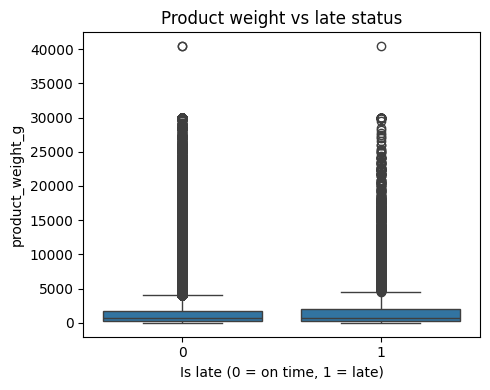

In [107]:
plt.figure(figsize=(5, 4))
sns.boxplot(
    data=df_eda,
    x="is_late",
    y="product_weight_g",
)
plt.xlabel("Is late (0 = on time, 1 = late)")
plt.ylabel("product_weight_g")
plt.title("Product weight vs late status")
plt.tight_layout()
plt.show()

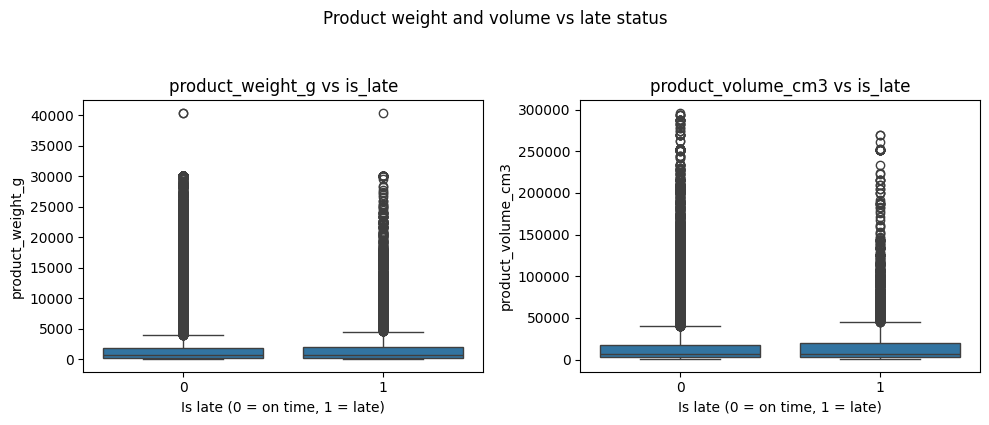

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, feat in zip(axes, ["product_weight_g", "product_volume_cm3"]):
    sns.boxplot(data=df_eda, x="is_late", y=feat, ax=ax)
    ax.set_xlabel("Is late (0 = on time, 1 = late)")
    ax.set_ylabel(feat)
    ax.set_title(f"{feat} vs is_late")

plt.suptitle("Product weight and volume vs late status", y=1.05)
plt.tight_layout()
plt.show()

In [109]:
bins = [0, 1e3, 5e3, 1e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–1k", "1k–5k", "5k–10k", "10k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

vol_late

,product_volume_bucket,total_orders,late_rate
0,0–1k,7828,0.077031
1,1k–5k,40081,0.078591
2,5k–10k,20339,0.073307
3,10k–50k,34706,0.080073
4,50k–100k,5685,0.093755
5,100k+,1539,0.103314


  product_volume_bucket  total_orders  late_rate
0                 0–500          1856   0.089440
1                500–1k          5972   0.073175
2                 1k–2k          9309   0.072618
3                 2k–5k         30772   0.080398
4                5k–10k         20339   0.073307
5               10k–20k         18169   0.079971
6               20k–50k         16537   0.080184
7              50k–100k          5685   0.093755
8                 100k+          1539   0.103314


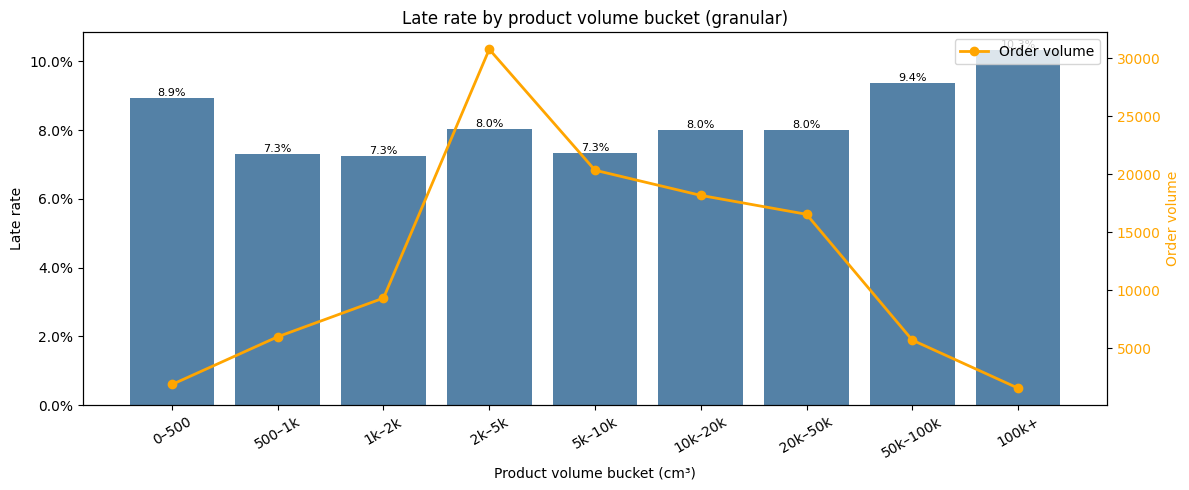

In [110]:
# Late rate by product volume bucket (more granular)
bins   = [0, 500, 1e3, 2e3, 5e3, 1e4, 2e4, 5e4, 1e5, df_eda["product_volume_cm3"].max()]
labels = ["0–500", "500–1k", "1k–2k", "2k–5k", "5k–10k", "10k–20k", "20k–50k", "50k–100k", "100k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=vol_late,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=8
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (granular)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(
    vol_late.index,
    vol_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

  product_volume_bucket  total_orders  late_rate
0                 0–50k        102954   0.077928
1                  50k+          7224   0.095792


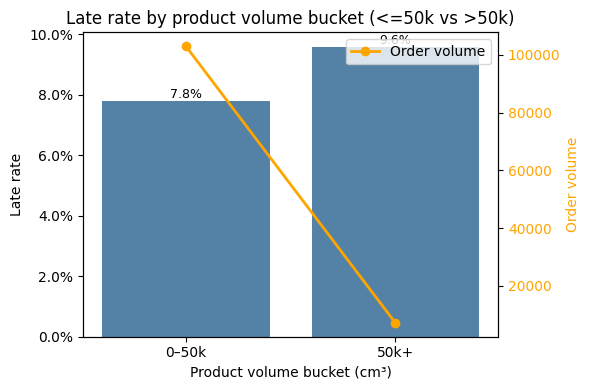

In [111]:
# Late rate by product volume bucket (2 buckets: <=50k and >50k cm³)
bins   = [0, 5e4, df_eda["product_volume_cm3"].max()]
labels = ["0–50k", "50k+"]

df_eda["product_volume_bucket"] = pd.cut(
    df_eda["product_volume_cm3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

vol_late_2 = (
    df_eda
    .groupby("product_volume_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(vol_late_2)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=vol_late_2,
    x="product_volume_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product volume bucket (cm³)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product volume bucket (<=50k vs >50k)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    vol_late_2.index,
    vol_late_2["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


  product_weight_bucket  total_orders  late_rate
0                 0–10k        105023   0.077773
1                  10k+          5155   0.106111


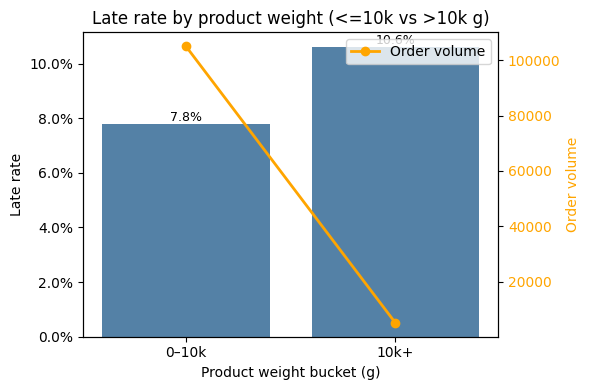

In [112]:
# Late rate by product weight bucket (2 buckets: <=10k and >10k g)
bins   = [0, 1e4, df_eda["product_weight_g"].max()]
labels = ["0–10k", "10k+"]

df_eda["product_weight_bucket"] = pd.cut(
    df_eda["product_weight_g"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

weight_late = (
    df_eda
    .groupby("product_weight_bucket", observed=True)
    .agg(
        total_orders=("is_late", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(weight_late)

# Bar chart: late rate + volume line
fig, ax1 = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=weight_late,
    x="product_weight_bucket",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax1.set_xlabel("Product weight bucket (g)")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product weight (<=10k vs >10k g)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    weight_late.index,
    weight_late["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

                product_category_name  total_orders  late_rate
0                     casa_conforto_2            24   0.166667
1           moveis_colchao_e_estofado            37   0.135135
2                               audio           348   0.127072
3      fashion_underwear_e_moda_praia           117   0.125984
4                    artigos_de_natal           125       0.12
5                     livros_tecnicos           256   0.110266
6                       casa_conforto           392   0.102564
7   construcao_ferramentas_iluminacao           242   0.099668
8                           alimentos           441   0.098196
9                         eletronicos          2517   0.097472
10                       beleza_saude          8649   0.090631
11                  moveis_escritorio          1254   0.089329
12                              bebes          2809    0.08786
13              instrumentos_musicais           611   0.086022
14                   moveis_decoracao          6307   0

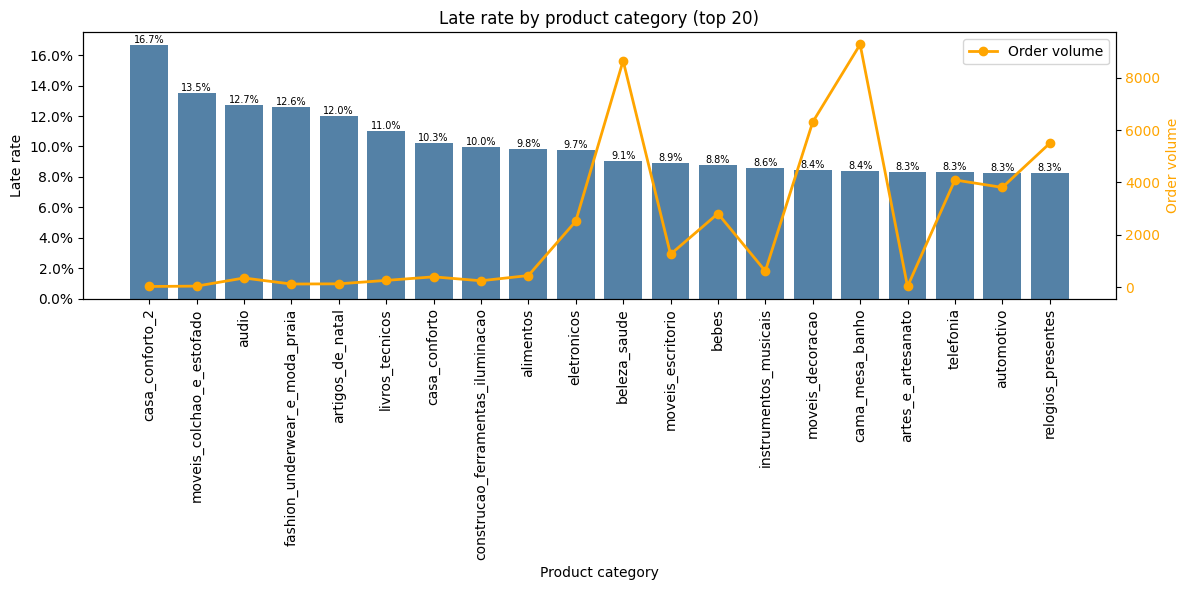

In [113]:
# Late rate by product category
category_late = (
    df[df["is_late"].notna()]
    .groupby("product_category_name")
    .agg(
        total_orders=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
    )
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(category_late.head(15))

# Plot top 20 categories by late rate
fig, ax1 = plt.subplots(figsize=(12, 6))

top20 = category_late.head(20)

sns.barplot(
    data=top20,
    x="product_category_name",
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

for p in ax1.patches:
    ax1.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=7
    )

ax1.set_xlabel("Product category")
ax1.set_ylabel("Late rate")
ax1.set_title("Late rate by product category (top 20)")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(
    top20.index,
    top20["total_orders"],
    color="orange",
    marker="o",
    linewidth=2,
    label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Product analysis – main findings

- **Volume and late rate**: the relationship between product volume and late delivery
  rate is not strictly monotonic. Mid-range volumes show comparable late rates to
  larger ones, suggesting volume alone is not a strong linear predictor.

- **Weight threshold**: orders with products weighing more than 10kg show a
  noticeably higher late rate, consistent with the hypothesis that heavier shipments
  face additional logistics constraints (e.g. special handling, carrier restrictions).

- **Feature engineering decision**: both continuous features (`product_weight_g`,
  `product_volume_cm3`) and binary flags (`is_heavy_product`, `is_bulky_product`)
  were retained. This allows linear models to use the thresholds directly while
  tree-based models can explore non-linear interactions.

- **Category late rate**: categories like `moveis_colchao_e_estofado` and
  `fashion_underwear_e_moda_praia` show consistently high late rates with
  sufficient volume to be statistically reliable. Low-volume categories such as
  `casa_conforto_2` should be interpreted with caution as their rates may reflect
  sampling noise rather than a structural pattern.

- **Similar category names**: some categories share near-identical names with a
  numeric suffix (e.g. `casa_conforto` and `casa_conforto_2`). These were
  intentionally kept separate, as the suffix may indicate distinct product lines
  with different logistics profiles. 

- **Feature engineering decision (category)**: given the high cardinality of
  `product_category_name`, target encoding (`category_late_rate`) is preferred
  over one-hot encoding to avoid dimensionality explosion while preserving
  predictive signal.

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64
        freight_bin  total_orders  late_rate
0    (-0.001, 8.73]          9472   0.057619
1     (8.73, 12.12]          9676    0.06167
2    (12.12, 14.02]          9791   0.054459
3    (14.02, 15.11]         10086   0.074698
4    (15.11, 16.26]          9563   0.082586
5    (16.26, 17.87]          9852   0.093425
6    (17.87, 19.41]          9945   0.080772
7    (19.41, 23.28]          9907   0.093682
8   (23.28, 34.041]          9945   0.089232
9  (34.041, 409.68]          9958   0.103259


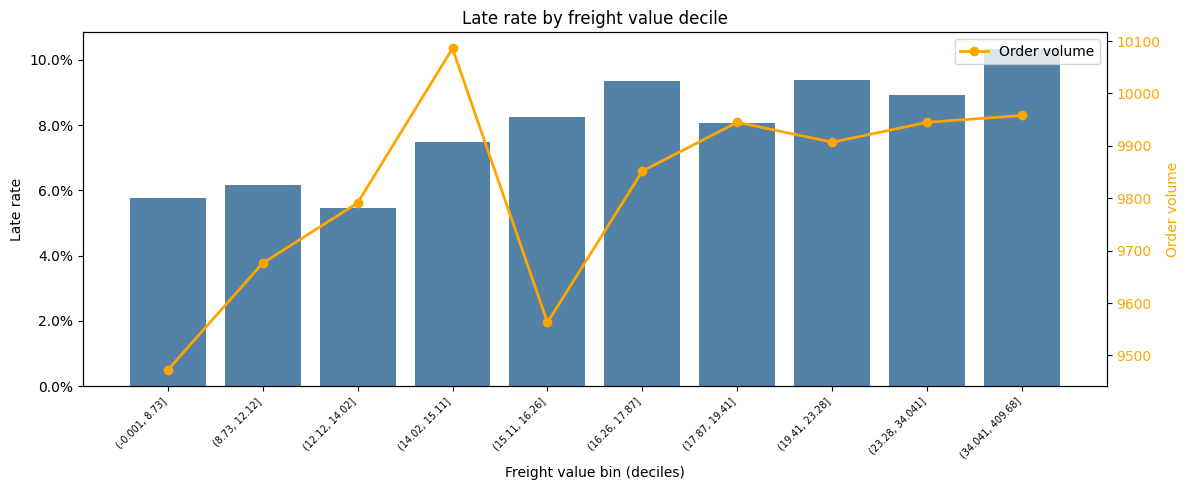

In [114]:
print(df["freight_value"].describe())

df["freight_bin"] = pd.qcut(df["freight_value"], q=10, duplicates="drop")

freight_late = (
    df[df["is_late"].notna()]
    .groupby("freight_bin", observed=True)
    .agg(
        total_orders=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(freight_late)

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=freight_late,
    x=freight_late.index,
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

ax1.set_xticks(freight_late.index)
ax1.set_xticklabels(
    [str(b) for b in freight_late["freight_bin"]],
    rotation=45, ha="right", fontsize=7
)
ax1.set_ylabel("Late rate")
ax1.set_xlabel("Freight value bin (deciles)")
ax1.set_title("Late rate by freight value decile")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    freight_late.index,
    freight_late["total_orders"],
    color="orange", marker="o", linewidth=2, label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

  payment_type_main  total_orders  late_rate
0            boleto         19191   0.086084
1        debit_card          1483   0.082374
2       credit_card         73103   0.077373
3           voucher          2698   0.071622


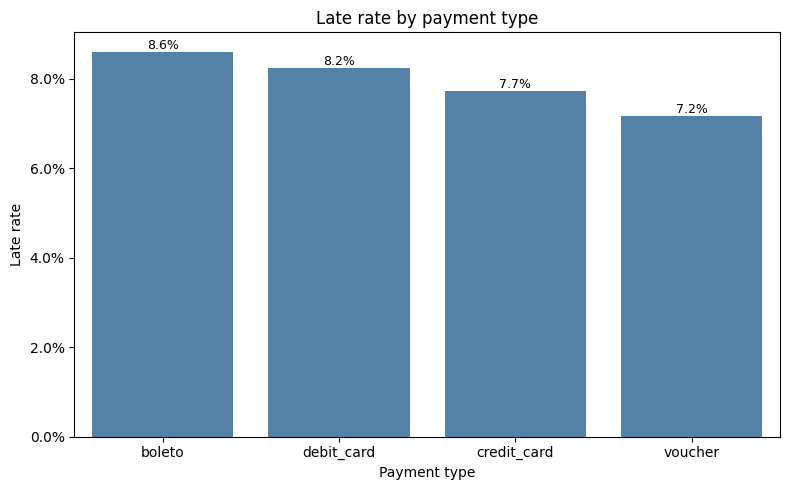

In [115]:
# Late rate by payment type
payment_late = (
    df[df["is_late"].notna()]
    .groupby("payment_type_main")
    .agg(
        total_orders=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
    )
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(payment_late)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=payment_late,
    x="payment_type_main",
    y="late_rate",
    color="steelblue",
    ax=ax,
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax.set_xlabel("Payment type")
ax.set_ylabel("Late rate")
ax.set_title("Late rate by payment type")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

         price_bin  total_orders  late_rate
0    (0.849, 23.8]          9120   0.071396
1     (23.8, 34.9]          9907   0.074158
2    (34.9, 47.49]          9091   0.067488
3    (47.49, 59.0]          9827   0.080082
4    (59.0, 74.99]          9738    0.07797
5    (74.99, 95.0]          9961   0.077983
6    (95.0, 119.9]         10510   0.079861
7   (119.9, 150.0]          9676   0.080422
8   (150.0, 229.8]         10120     0.0844
9  (229.8, 6735.0]         10375   0.097213


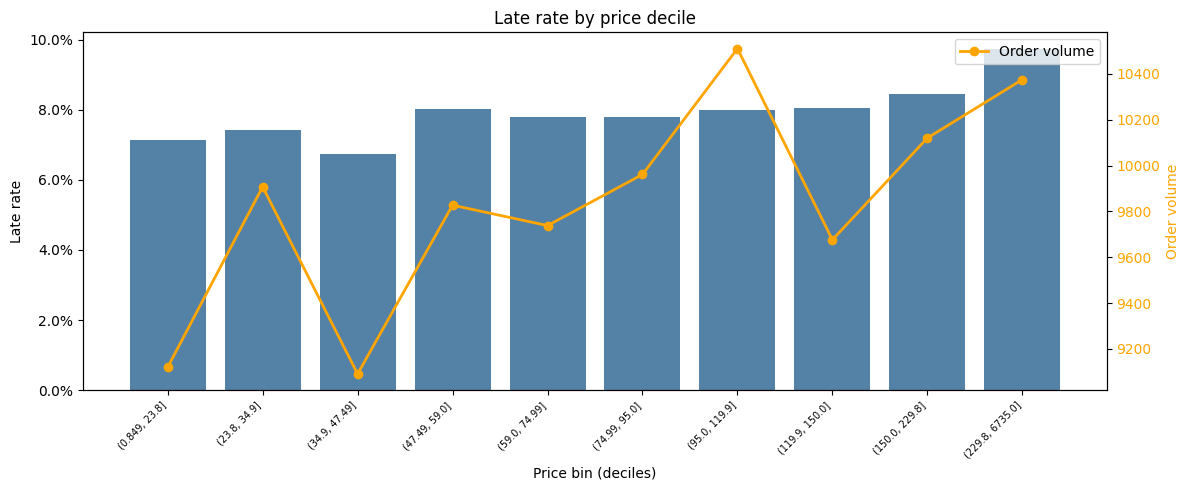

In [116]:
# Late rate by price bin
df["price_bin"] = pd.qcut(df["price"], q=10, duplicates="drop")

price_late = (
    df[df["is_late"].notna()]
    .groupby("price_bin", observed=True)
    .agg(
        total_orders=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(price_late)

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=price_late,
    x=price_late.index,
    y="late_rate",
    color="steelblue",
    ax=ax1,
)

ax1.set_xticks(price_late.index)
ax1.set_xticklabels(
    [str(b) for b in price_late["price_bin"]],
    rotation=45, ha="right", fontsize=7
)
ax1.set_ylabel("Late rate")
ax1.set_xlabel("Price bin (deciles)")
ax1.set_title("Late rate by price decile")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(
    price_late.index,
    price_late["total_orders"],
    color="orange", marker="o", linewidth=2, label="Order volume"
)
ax2.set_ylabel("Order volume", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Payment type & price findings

- **Payment type**: late rates range narrowly from 7.2% (voucher) to 8.6% (boleto),
  suggesting payment type carries limited standalone predictive signal. The slight
  boleto premium may reflect processing delays inherent to this payment method.
  Feature will be retained as a low-cost categorical input.

- **Price**: late rate shows a mild positive linear trend with price, rising from
  ~7.1% in the lowest decile (< R$23.8) to ~9.2% in the highest (> R$229.8).
  The continuous `price` feature will be retained as-is, with no binary flag needed
  given the absence of abrupt threshold effects.

- **Freight value**: retained as an independent feature alongside `price`. Although
  correlated with product weight, it may carry unique signal from route distance,
  remote delivery zones, or shipping modalities. Multicollinearity is not a concern
  given the tree-based modeling approach. Feature importance post-training will
  determine whether it is dropped during feature selection.

In [117]:
# Late rate by seller
seller_late = (
    df[df["is_late"].notna()]
    .groupby("seller_id")
    .agg(
        total_orders=("order_id", "nunique"),
        late_rate=("is_late", "mean"),
    )
    .query("total_orders >= 30")
    .sort_values("late_rate", ascending=False)
    .reset_index()
)

print(seller_late.head(20))

                           seller_id  total_orders  late_rate
0   ede0c03645598cdfc63ca8237acbe73d            43   0.340426
1   54965bbe3e4f07ae045b90b0b8541f52            73   0.320988
2   ad781527c93d00d89a11eecd9dcad7c1            38   0.315789
3   835f0f7810c76831d6c7d24c7a646d4d            42     0.3125
4   2a1348e9addc1af5aaa619b1a3679d6b            48   0.294118
5   66e0557ecc2b4dbea057e93f215f68d8            30   0.266667
6   71039d19d4303bf9054d69e9a9236699            35   0.263158
7   6039e27294dc75811c0d8a39069f52c0            63   0.256757
8   ef990a83bbea832f36ebe81376335aa8            43       0.25
9   a49928bcdf77c55c6d6e05e09a9b4ca5            96       0.25
10  602044f2c16190c2c6e45eb35c2e21cb            48   0.236364
11  06a2c3af7b3aee5d69171b0e14f0ee87           389   0.236318
12  beadbee30901a7f61d031b6b686095ad            64   0.235294
13  cac4c8e7b1ca6252d8f20b2fc1a2e4af            74   0.231707
14  ea566164622c6b439516ab18062c42cd            50   0.230769
15  99a5

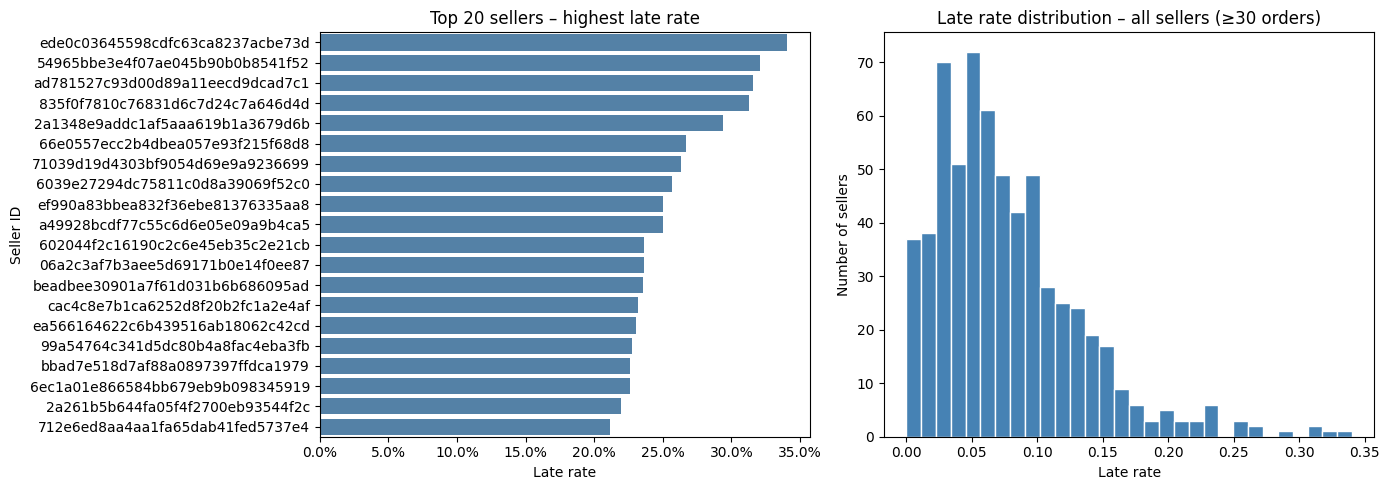

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 worst sellers
sns.barplot(
    data=seller_late.head(20),
    x="late_rate",
    y="seller_id",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Top 20 sellers – highest late rate")
axes[0].set_xlabel("Late rate")
axes[0].set_ylabel("Seller ID")
axes[0].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

# Distribution of late rate across all sellers
axes[1].hist(seller_late["late_rate"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Late rate distribution – all sellers (≥30 orders)")
axes[1].set_xlabel("Late rate")
axes[1].set_ylabel("Number of sellers")

plt.tight_layout()
plt.show()

### Seller findings

- **Seller late rate**: distribution is right-skewed, with most sellers concentrated
  between 3–10% late rate. A long tail reaches up to ~34%, indicating that a small
  subset of sellers is responsible for a disproportionate share of delays.
  The top 20 worst sellers range from 21% to 34%, well above the global average.
  Given high cardinality, `seller_id` will be encoded via k-fold target encoding,
  expected to be a strong predictive feature.

In [119]:
review_late = (
    df[df["is_late"].notna()]
    .groupby("review_score")
    .agg(
        total_orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

print(review_late)

   review_score  total_orders  late_rate
0           1.0         12498   0.319731
1           2.0          3672   0.178649
2           3.0          9190   0.103047
3           4.0         21072   0.048738
4           5.0         62937   0.030094


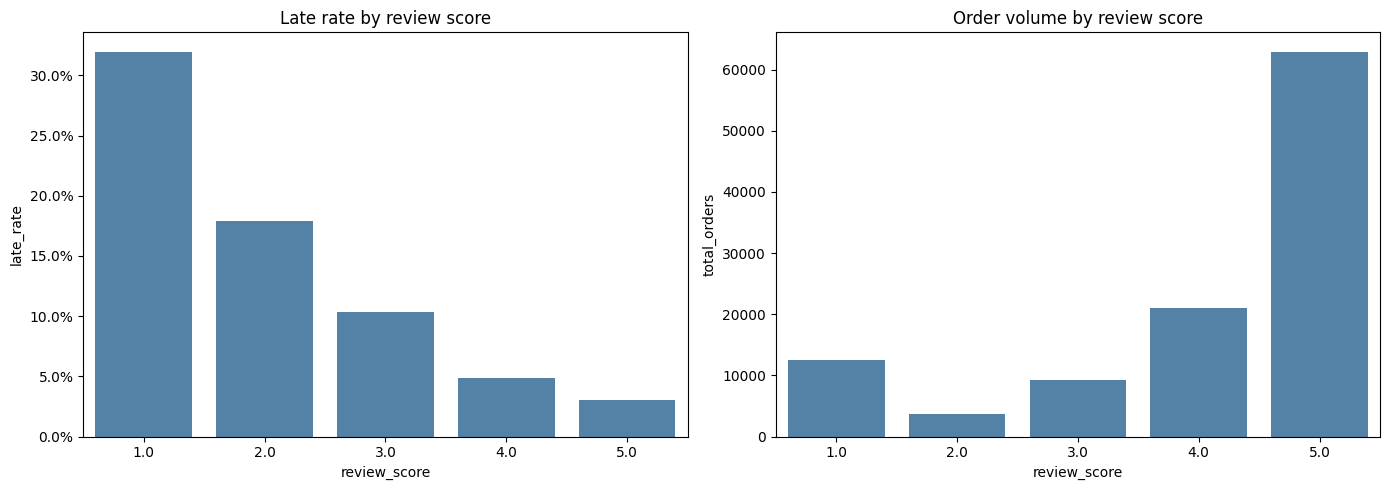

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=review_late,
    x="review_score",
    y="late_rate",
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Late rate by review score")
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

sns.barplot(
    data=review_late,
    x="review_score",
    y="total_orders",
    color="steelblue",
    ax=axes[1],
)
axes[1].set_title("Order volume by review score")

plt.tight_layout()
plt.show()

### Review score findings

- **Review score**: strong monotonic relationship with late rate. Score 1 reaches
  32% late rate — over 10x higher than score 5 (3%). The relationship is smooth
  and consistent across all levels, confirming `review_score` can be used as a
  continuous numeric feature without encoding. Volume is heavily concentrated
  at score 5 (~63k orders), suggesting most customers are satisfied, while
  dissatisfied reviews are disproportionately driven by late deliveries.

In [121]:
# Overview of review comment column
print(df["review_comment_message"].isna().mean())
print(df["review_comment_message"].dropna().str.len().describe())

# Sample comments
df["review_comment_message"].dropna().sample(10, random_state=42).tolist()

0.579138925876609
count    47410.000000
mean        70.221198
std         54.511892
min          1.000000
25%         29.000000
50%         54.000000
75%         98.000000
max        208.000000
Name: review_comment_message, dtype: float64


['Otima compra e a entrega super rapida...',
 'Excelente qualidade .. recomendo o produto',
 'Muito satisfeita. Produto entregue antes do prazo. Tudo em perfeita ordem.',
 'Ótimo',
 'so veio um produto, pedi tres.',
 'Vou começar a usar espero por resultados favoráveis!!! ',
 'tudo 100%',
 'muito bom\r\n',
 'Comprei dois perfumes, o Tommy Hilfiger recebi caixa lacrada parece ok, mas o perfume da Gabriela Sabatini a caixa está sem lacre e tem etiqueta auto adesiva fundo do frasco lado externo. Será falso??',
 'bom']

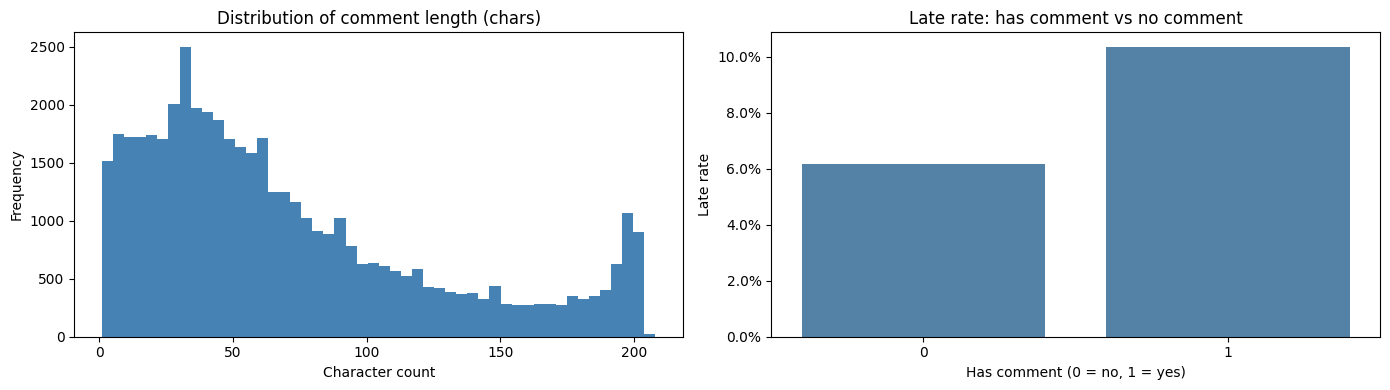

   has_comment  total_orders  late_rate
0            0         64283   0.061618
1            1         45913   0.103544


In [122]:
df_comments = df["review_comment_message"].dropna().copy()

# Comment length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of character length
df_comments.str.len().plot.hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of comment length (chars)")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Frequency")

# Late rate: has comment vs no comment
df["has_comment"] = df["review_comment_message"].notna().astype("Int8")

comment_late = (
    df[df["is_late"].notna()]
    .groupby("has_comment")
    .agg(
        total_orders=("order_id", "count"),
        late_rate=("is_late", "mean"),
    )
    .reset_index()
)

sns.barplot(
    data=comment_late,
    x="has_comment",
    y="late_rate",
    color="steelblue",
    ax=axes[1],
)
axes[1].set_title("Late rate: has comment vs no comment")
axes[1].set_xlabel("Has comment (0 = no, 1 = yes)")
axes[1].set_ylabel("Late rate")
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(comment_late)

### Review comment findings

- **Missing rate**: 57.9% of orders have no review comment, making
  `has_comment` a meaningful binary signal on its own (supported by the difference in is_late rate)
- **Comment length**: median 54 chars, max 208 — short texts, well within
  BERT's 512-token limit with no truncation concern.
- **Late rate signal**: orders with comments show ~10.3% late rate vs ~6.1%
  for orders without, suggesting dissatisfied customers are more likely to
  comment. BERT embeddings will capture semantic content beyond this binary
  signal.
- **Feature engineering**: `has_comment` binary flag will be retained
  alongside BERT `[CLS]` embeddings reduced via SVD to ~50 components.

In [123]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_unique_id', 'customer_city',
       'customer_state', 'review_comment_message', 'review_score',
       'product_category_name', 'product_weight_g', 'payment_type_main',
       'seller_geo_city', 'seller_geo_state', 'customer_geo_city',
       'customer_geo_state', 'seller_customer_distance_km', 'is_late',
       'product_volume_cm3', 'is_heavy_product', 'is_bulky_product',
       'has_comment', 'bert_svd_0', 'bert_svd_1', 'bert_svd_2', 'bert_svd_3',
       'bert_svd_4', 'bert_svd_5', 'bert_svd_6', 'bert_svd_7', 'bert_svd_8',
       'bert_svd_9', 'bert_svd_10', 'bert_svd_11', 'bert_svd_12',
       'bert_svd_13', 'bert_svd_14', 'bert_svd_15', 'bert_svd_16',
       '

In [124]:
df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,bert_svd_46,bert_svd_47,bert_svd_48,bert_svd_49,actual_delivery_days,estimated_delivery_days,delay_vs_estimated_days,purchase_month,freight_bin,price_bin
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,-0.437916,0.755499,0.160171,-0.121071,8.0,15,-7.0,2017-10,"(-0.001, 8.73]","(23.8, 34.9]"
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,-0.200264,0.136254,-0.166536,0.043802,13.0,19,-6.0,2018-07,"(19.41, 23.28]","(95.0, 119.9]"
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,0.000843,-0.000631,-0.002070,-0.001148,9.0,26,-17.0,2018-08,"(17.87, 19.41]","(150.0, 229.8]"
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,0.005328,-0.367307,-0.231086,0.072944,13.0,26,-13.0,2017-11,"(23.28, 34.041]","(34.9, 47.49]"
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,0.000843,-0.000631,-0.002070,-0.001148,2.0,12,-10.0,2018-02,"(-0.001, 8.73]","(0.849, 23.8]"
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,...,0.000843,-0.000631,-0.002070,-0.001148,16.0,22,-6.0,2017-07,"(23.28, 34.041]","(119.9, 150.0]"
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09,1,a1804276d9941ac0733cfd409f5206eb,...,0.297131,-0.240137,-0.113701,-0.641558,NaN,27,NaN,2017-04,"(15.11, 16.26]","(47.49, 59.0]"
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,...,0.000843,-0.000631,-0.002070,-0.001148,9.0,21,-12.0,2017-05,"(15.11, 16.26]","(59.0, 74.99]"
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,1,ac1789e492dcd698c5c10b97a671243a,...,0.000843,-0.000631,-0.002070,-0.001148,9.0,41,-32.0,2017-01,"(15.11, 16.26]","(0.849, 23.8]"
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,1,9a78fb9862b10749a117f7fc3c31f051,...,0.000843,-0.000631,-0.002070,-0.001148,18.0,24,-6.0,2017-07,"(19.41, 23.28]","(119.9, 150.0]"


In [126]:
df['order_status'].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64